In [1]:
from downscaled_climate_data.processors.era5_processor import era5_processing
from shapely.geometry import mapping

import xarray as xr
import geopandas as gpd
import dask_geopandas as dgpd
from geocube.api.core import make_geocube

import dask.dataframe as dd

from htcdaskgateway import HTCGateway
from dask_gateway.auth import BasicAuth

import os
from dotenv import load_dotenv

load_dotenv()  # take environment variables from .env.


True

# Connect to Dask Cluster
Click on dashboard link to monitor tasks in the cluster

In [2]:
os.environ['CONDOR_BIN_DIR'] = "/u/bengal1/.conda/envs/downscaled_climate_data/bin"
os.environ['CONDOR_CONFIG'] = "/u/bengal1/.conda/envs/downscaled_climate_data/etc/condor/condor_config"
gateway = HTCGateway(address="https://dask.software-dev.ncsa.illinois.edu",
                     proxy_address=8786,
                     auth = BasicAuth(
                         username=None, 
                         password=os.environ['DASK_GATEWAY_PASSWORD'])
                    )
cluster = gateway.new_cluster(image="bengal1/pangeo-ncsa:dev", 
                              container_image="/u/bengal1/condor/pangeo.sif")
cluster.scale(80)
client = cluster.get_client()

client


INFO:htcdaskgateway.HTCGateway: Creating HTCGatewayCluster 
INFO:htcdaskgateway.GatewayCluster: Scaling: 80 HTCondor workers
INFO:htcdaskgateway.GatewayCluster: Sandbox : /u/bengal1/htcdask/dask.7ab9decd6d174be69a90d72cdf1d63e0
INFO:htcdaskgateway.GatewayCluster: Submitting HTCondor job(s) for 80 workers with command: . ~/.profile && /u/bengal1/.conda/envs/downscaled_climate_data/bin/condor_submit htcdask_submitfile.jdl | grep -oP '(?<=cluster )[^ ]*'
INFO:htcdaskgateway.GatewayCluster: Success! submitted HTCondor jobs to htc-login1.campuscluster.illinois.edu with  ClusterId 2377


/u/bengal1/.conda/envs/downscaled_climate_data/lib/python3.11/site-packages/distributed/client.py:1612: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| tornado | 6.5.1  | 6.5.2     | None    |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


Connection method: Cluster object,Cluster type: htcdaskgateway.HTCGatewayCluster
Dashboard: https://dask.software-dev.ncsa.illinois.edu/clusters/dask.7ab9decd6d174be69a90d72cdf1d63e0/status,


In [ ]:
cluster.close()

In [3]:
import s3fs

fs = s3fs.S3FileSystem(
    endpoint_url=os.environ['S3_ENDPOINT_URL'],
    key=os.environ['AWS_ACCESS_KEY_ID'],
    secret=os.environ['AWS_SECRET_ACCESS_KEY'],
    config_kwargs={
        'signature_version': 's3v4',
        's3': {
            'addressing_style': 'path'
        }
    })


In [6]:
counties = gpd.read_parquet("s3://ees240146/shapefiles/tiger/2024/COUNTY/tl_2024_us_county.parquet/STATEFP=17/tl_2024_us_county.parquet")
counties = counties.to_crs("EPSG:4326")
# Convert GeoPandas to Dask for later joins
counties_dask = dd.from_pandas(counties[['GEOID', 'STATEFP', 'NAME']], npartitions=1)
counties_dask.persist()
counties_dask.compute()

,GEOID,STATEFP,NAME
85,17067,17,Hancock
91,17025,17,Clay
130,17185,17,Wabash
147,17113,17,McLean
157,17005,17,Bond
...,...,...,...
2901,17111,17,McHenry
2922,17015,17,Carroll
2989,17047,17,Edwards
2998,17071,17,Henderson


In [12]:
# Make sure GEOID has a numeric value since we can't rasterize a string
counties['GEOID'] = counties['GEOID'].astype('int64')

county_raster = make_geocube(
    vector_data=counties,
    measurements=['GEOID'],
    resolution=(-0.015, 0.015),  # Use a small enough grid size to capture the shape of the counties
    output_crs='EPSG:4326',
    fill=0  # Use 0 instead of NaN for empty cells
).rename({'x': 'lon', 'y': 'lat'})

county_raster.info()

INFO:botocore.credentials:Found credentials in environment variables.
INFO:botocore.credentials:Found credentials in environment variables.
xarray.Dataset {
dimensions:
	lat = 370 ;
	lon = 300 ;

variables:
	int64 GEOID(lat, lon) ;
		GEOID:name = GEOID ;
		GEOID:long_name = GEOID ;
		GEOID:_FillValue = 0 ;
	float64 lat(lat) ;
		lat:axis = Y ;
		lat:long_name = latitude ;
		lat:standard_name = latitude ;
		lat:units = degrees_north ;
	float64 lon(lon) ;
		lon:axis = X ;
		lon:long_name = longitude ;
		lon:standard_name = longitude ;
		lon:units = degrees_east ;
	int64 spatial_ref() ;
		spatial_ref:crs_wkt = GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]] ;
		spatial_ref:semi_major_axis = 6378137.0 ;
		spatial_ref:semi_minor_axis = 63567

## Clip ERA5 data to state Boundries

In [13]:
state_shapes = gpd.read_parquet("ees240146/shapefiles/tiger/2024/STATE/tl_2024_us_state.parquet", filesystem=fs)
state_gps = state_shapes.to_crs("EPSG:4326")
geometry = state_gps[state_gps['STATEFP'] == '17'].geometry.iloc[0]

# Expand bounds to pick up at least one point outside of the state
expanded = tuple(x + 0.25 for x in geometry.bounds)
minx, miny, maxx, maxy = expanded

In [38]:
variables = {
    '2m_temperature',
    'total_precipitation',
    "sfcWind",
    "vapor_pressure",
    "surface_pressure",
    "relative_humidity"
}
    
era5 = era5_processing(variables, 2023, 2023, 
                       (minx % 360, maxx % 360, miny, maxy), # Convert bounding box to 0/360 notation
                       chunks=750)

daily_average = era5.resample(time='1D').mean() # Is mean correct for all variables? min or max?

# Convert longitude from 0-360 to -180/180
era5_converted = daily_average.assign_coords(lon=(((daily_average.lon + 180) % 360) - 180))
era5_converted

Opening dataset: ...
Dataset opened in 0.61 seconds
Selecting time range...
Time range selection completed in 0.20 seconds
-----
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
Lat bounds: 0.0 to 359.75
Lon bounds: 0.0 to 359.75
Time bounds: 2023-01-01T00:00:00.000000000 to 2023-12-31T23:00:00.000000000
Filtering for Specified region...268.736921, 273.23006499999997, 37.220298, 42.758481
Region filtering completed in 0.03 seconds
<xarray.Dataset> Size: 87MB
Dimensions:                  (time: 8760, lat: 23, lon: 18)
Coordinates:
  * lat                      (lat) float32 92B 42.75 42.5 42.25 ... 37.5 37.25
  * lon                      (lon) float32 72B 268.8 269.0 269.2 ... 272.8 273.0
  * time                     (time) datetime64[ns] 70kB 2023-01-01 ... 2023-1...
Data variables:
    2m_dew

<xarray.Dataset> Size: 5MB
Dimensions:                  (time: 365, lat: 23, lon: 18)
Coordinates:
  * lat                      (lat) float32 92B 42.75 42.5 42.25 ... 37.5 37.25
  * time                     (time) datetime64[ns] 3kB 2023-01-01 ... 2023-12-31
  * lon                      (lon) float32 72B -91.25 -91.0 ... -87.25 -87.0
Data variables:
    2m_dewpoint_temperature  (time, lat, lon) float32 604kB dask.array<chunksize=(13, 23, 18), meta=np.ndarray>
    10m_v_component_of_wind  (time, lat, lon) float32 604kB dask.array<chunksize=(13, 23, 18), meta=np.ndarray>
    total_precipitation      (time, lat, lon) float32 604kB dask.array<chunksize=(13, 23, 18), meta=np.ndarray>
    10m_u_component_of_wind  (time, lat, lon) float32 604kB dask.array<chunksize=(13, 23, 18), meta=np.ndarray>
    surface_pressure         (time, lat, lon) float32 604kB dask.array<chunksize=(13, 23, 18), meta=np.ndarray>
    2m_temperature           (time, lat, lon) float32 604kB dask.array<chunksize=(13, 23, 18), meta=np.ndarray>
    relative_humidity        (time, lat, lon) float32 604kB dask.array<chunksize=(13, 23, 18), meta=np.ndarray>
    vapor_pressure           (time, lat, lon) float32 604kB dask.array<chunksize=(13, 23, 18), meta=np.ndarray>
    sfcWind                  (time, lat, lon) float32 604kB dask.array<chunksize=(13, 23, 18), meta=np.ndarray>
Attributes:
    valid_time_start:       1940-01-01
    last_updated:           2025-08-11 01:47:04.229222+00:00
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-08-05

In [39]:
results_list = []

for i, variable in enumerate(variables):
    era5_measure = era5_converted[variable].rio.set_spatial_dims(x_dim='lon', y_dim='lat')
    era5_measure = era5_measure.rio.write_crs('EPSG:4326')

    # Perform spatial interpolation to align the county_raster dataset with 
    # the coordinate grid of the era5 dataset.
    era5_interp = era5_measure.interp(
        lat=county_raster.lat,
        lon=county_raster.lon,
        method='cubic'
    )
    
    era5_aligned, county_aligned = xr.align(era5_interp, county_raster, join='inner')
    county_labels = county_aligned['GEOID']
    county_stats = era5_aligned.groupby(county_labels).mean(dim=['lon', 'lat'])
    single_var_df = county_stats.to_dask_dataframe()

    # Dask only supports a single index key. Generate a technical one
    # to represent our two keys, time and GEOID
    single_var_df['time_geoid_key'] = single_var_df['time'].astype(str) + '_' + single_var_df['GEOID'].astype(str)

    # For the first variable we process, include the coordinates -
    # later variables don't need these since we will join on GEOID and time
    # and this will just duplicate the coordinate colums on each join
    if i == 0:
        single_var_df = single_var_df[["time_geoid_key", "time", "GEOID", variable]]
        results_list.append(single_var_df.set_index('time_geoid_key'))
    else:
        # For subsequent dataframes, drop coordinate columns except GEOID
        columns_to_keep = ['time_geoid_key', variable]
        single_var_df = single_var_df[columns_to_keep]
        results_list.append(single_var_df.set_index('time_geoid_key'))

len(results_list)

6

In [ ]:
# Merge all dataframes on the multi-index
combined_df = results_list[0]
for df in results_list[1:]:
    combined_df = combined_df.join(df, how='outer')

# Force type consistency on the two tables. 
counties_dask['GEOID'] = counties_dask['GEOID'].astype('string')
combined_df['GEOID'] = combined_df['GEOID'].astype('string')

# And join with counties shapefiles to get some more fields from there
final_df = combined_df.merge(counties_dask, on='GEOID', how='left')

# Filter out the rows for mismatches
final_df = final_df[final_df['GEOID'] != '0']
final_df.to_parquet(f's3://ees240146/analysis/era5/v0.01/COUNTY/YEAR=2023/era5_county.parquet',
                    filesystem=fs)


## Diagnostic Plots

In [29]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:


# Create the visualization
fig, ax = plt.subplots(1, 1, figsize=(15, 10), 
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Extract the GEOID data from your raster
geoid_data = county_raster['GEOID'].values
lon_coords = county_raster['lon'].values
lat_coords = county_raster['lat'].values

# Get unique GEOIDs (excluding fill value of 0)
unique_geoids = np.unique(geoid_data[geoid_data != 0])
n_counties = len(unique_geoids)

# Create a colormap with enough colors for all unique GEOIDs
# Using a qualitative colormap that works well for categorical data
if n_counties <= 10:
    colors = plt.cm.Set3(np.linspace(0, 1, n_counties))
elif n_counties <= 20:
    colors = plt.cm.tab20(np.linspace(0, 1, n_counties))
else:
    # For many counties, use a continuous colormap
    colors = plt.cm.viridis(np.linspace(0, 1, n_counties))

# Create colormap and normalization
cmap = ListedColormap(['white'] + list(colors))  # White for background (0 values)

# Create a mapping from GEOID to color index
geoid_to_index = {0: 0}  # Background
for i, geoid in enumerate(unique_geoids):
    geoid_to_index[geoid] = i + 1

# Map the data to color indices
color_data = np.zeros_like(geoid_data)
for geoid, idx in geoid_to_index.items():
    color_data[geoid_data == geoid] = idx

# Create the plot
im = ax.imshow(color_data, 
               extent=[lon_coords.min(), lon_coords.max(), 
                      lat_coords.min(), lat_coords.max()],
               cmap=cmap, 
               vmin=0, 
               vmax=n_counties,
               aspect='auto',
               origin='upper',
               transform=ccrs.PlateCarree())

# Set the map extent to fit the data
ax.set_extent([lon_coords.min(), lon_coords.max(), 
               lat_coords.min(), lat_coords.max()], 
              crs=ccrs.PlateCarree())


# Set labels and title
ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title(f'County GEOID Raster Visualization\n{n_counties} Counties', 
             fontsize=16, fontweight='bold', pad=20)

# Add gridlines
ax.grid(True, alpha=0.3, linestyle='--')

# Create custom legend showing GEOID values
legend_elements = []
for i, geoid in enumerate(unique_geoids[:20]):  # Show first 20 for readability
    color = colors[i] if i < len(colors) else colors[0]
    legend_elements.append(patches.Patch(color=color, label=f'GEOID: {int(geoid)}'))

# Add legend outside the plot
if len(unique_geoids) <= 20:
    ax.legend(handles=legend_elements, 
             bbox_to_anchor=(1.05, 1), 
             loc='upper left',
             fontsize=9,
             title='County GEOIDs',
             title_fontsize=10,
             title_fontweight='bold')
else:
    # For many counties, add a colorbar instead
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('GEOID Index', fontsize=12, fontweight='bold')

# Add statistics text box
stats_text = f"""Dataset Statistics:
• Total pixels: {geoid_data.size:,}
• Unique counties: {n_counties}
• Resolution: {geoid_data.shape[1]} × {geoid_data.shape[0]}
• Longitude range: {lon_coords.min():.3f} to {lon_coords.max():.3f}
• Latitude range: {lat_coords.min():.3f} to {lat_coords.max():.3f}
• Non-zero pixels: {np.sum(geoid_data != 0):,} ({100*np.sum(geoid_data != 0)/geoid_data.size:.1f}%)"""

ax.text(0.02, 0.98, stats_text, 
        transform=ax.transAxes, 
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', 
                 facecolor='white', 
                 alpha=0.8,
                 edgecolor='gray'))

# Adjust layout to prevent clipping
plt.tight_layout()


# Display the plot
plt.show()

# Print summary information
print(f"\n📊 Raster Summary:")
print(f"   • Shape: {geoid_data.shape}")
print(f"   • Unique GEOIDs: {n_counties}")
print(f"   • Coordinate extent:")
print(f"     - Longitude: {lon_coords.min():.4f} to {lon_coords.max():.4f}")
print(f"     - Latitude: {lat_coords.min():.4f} to {lat_coords.max():.4f}")
print(f"   • Data coverage: {100*np.sum(geoid_data != 0)/geoid_data.size:.1f}% of pixels contain county data")

# Show first few unique GEOIDs as examples
print(f"\n🏘️  Sample GEOIDs: {unique_geoids[:10].tolist()}")
if len(unique_geoids) > 10:
    print(f"   ... and {len(unique_geoids) - 10} more")

In [32]:
date_to_plot = '2023-12-31'
counties['GEOID'] = counties['GEOID'].astype(str)
era5_dec31 = final_df[final_df['time'] == date_to_plot].compute()
merged_gdf = counties.merge(era5_dec31, on='GEOID', how='left')


In [36]:
era5_dec31['2m_temperature'].min()

272.68255615234375

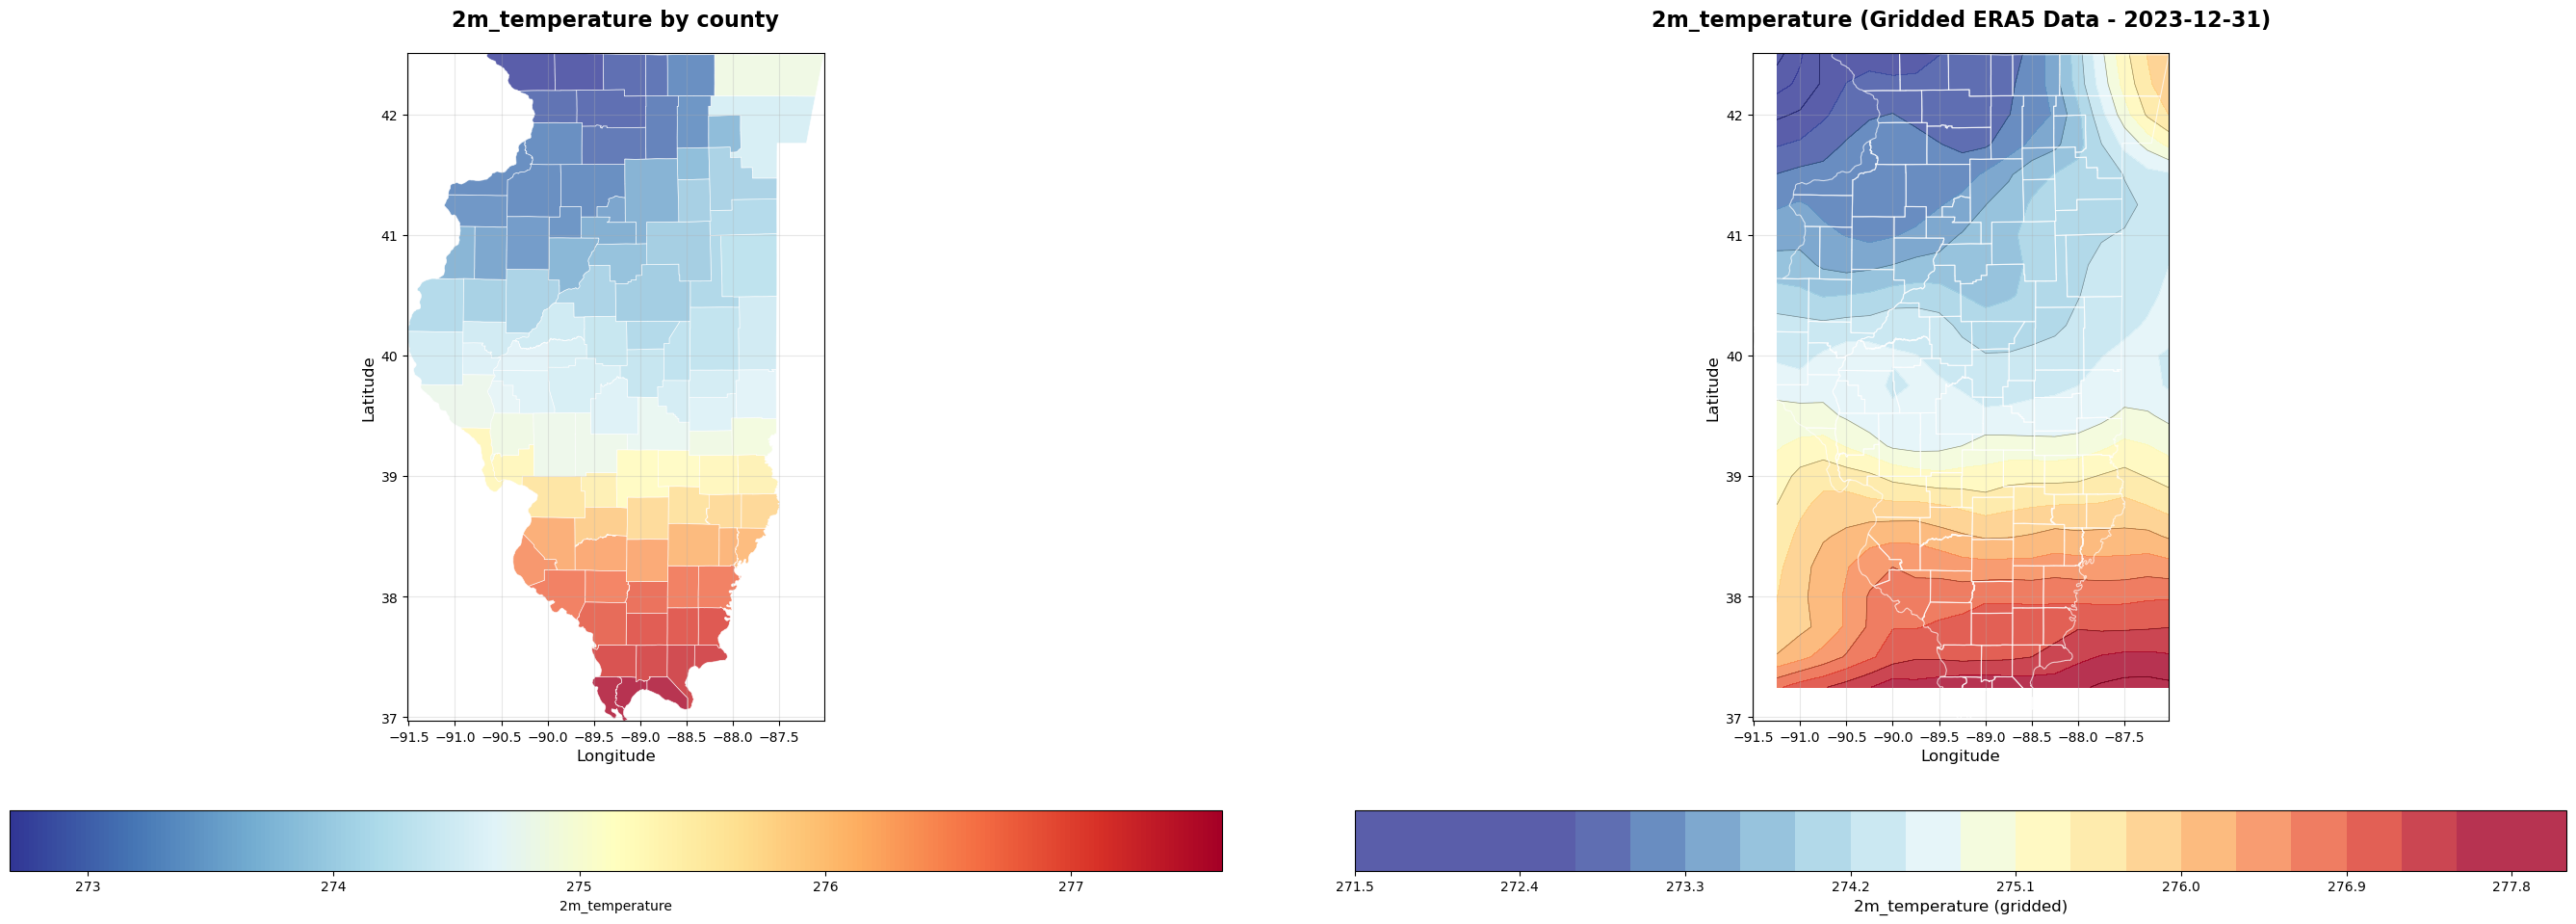

In [37]:
column = "2m_temperature"

# Calculate the overall temperature range for consistent color scaling
temp_min = era5_dec31['2m_temperature'].min()
temp_max = era5_dec31['2m_temperature'].max()

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))  # 1 row, 2 columns

# Plot counties with wind data
merged_gdf.plot(
    column=column,
    cmap='RdYlBu_r',  # Red-Yellow-Blue colormap (reversed)
    linewidth=0.5,
    edgecolor='white',
    alpha=0.8,
    legend=True,
    legend_kwds={
        'label': column,
        'orientation': "horizontal",
        'shrink': 0.8,
        'pad': 0.1
    },
    ax=ax1,
    vmin=temp_min,  # Set minimum value
    vmax=temp_max,  # Set maximum value
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No data",
    }
)

# Customize the plot
ax1.set_title(f'{column} by county', 
            fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)

# Remove axis ticks for cleaner look
ax1.tick_params(axis='both', which='major', labelsize=10)

# Add a subtle grid
ax1.grid(True, alpha=0.3)

#### Second Plot - Direct from xArray

# Filter data for specific date
era5_dec31 = era5_converted.sel(time='2023-12-31')

# Extract coordinates and temperature data
lons = era5_dec31.lon.values
lats = era5_dec31.lat.values
temp_data = era5_dec31['2m_temperature'].values

# Create contour plot
contour = ax2.contourf(lons, lats, temp_data, 
                      levels=20,  # Number of contour levels
                      cmap='RdYlBu_r',  # Same colormap as first plot
                      alpha=0.8,
                      vmin=temp_min,  # Same minimum as first plot
                      vmax=temp_max)  # Same maximum as first plot


# Add contour lines
contour_lines = ax2.contour(lons, lats, temp_data, 
                           levels=10,  # Fewer levels for lines
                           colors='black', 
                           alpha=0.4, 
                           linewidths=0.5,
                           vmin=temp_min,  # Same minimum as first plot
                           vmax=temp_max)  # Same maximum as first plot

# Add county boundaries on top
merged_gdf.boundary.plot(ax=ax2, 
                        color='white', 
                        linewidth=0.8, 
                        alpha=0.7)

# Add colorbar for second subplot
cbar = plt.colorbar(contour, ax=ax2, orientation='horizontal', 
                   shrink=0.8, pad=0.1)
cbar.set_label('2m_temperature (gridded)', fontsize=12)

# Customize second subplot
ax2.set_title('2m_temperature (Gridded ERA5 Data - 2023-12-31)', 
             fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=10)
ax2.grid(True, alpha=0.3)

# Set same extent for both plots (optional, for better comparison)
bounds = merged_gdf.total_bounds  # [minx, miny, maxx, maxy]
ax1.set_xlim(bounds[0], bounds[2])
ax1.set_ylim(bounds[1], bounds[3])
ax2.set_xlim(bounds[0], bounds[2])
ax2.set_ylim(bounds[1], bounds[3])


plt.tight_layout()
plt.show()

In [ ]:
wind_data = wind_u.sel(time=date_to_plot, method='nearest')

# Create the figure and axis with EPSG:4326 projection (PlateCarree)
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add state boundaries for better context
ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='black')
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.5)
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.5)

# Create scatter plot with individual data points
# Flatten the lat/lon and data arrays for scatter plotting
lon_flat = wind_data.lon.values
lat_flat = wind_data.lat.values
lon_mesh, lat_mesh = np.meshgrid(lon_flat, lat_flat)
lon_points = lon_mesh.flatten()
lat_points = lat_mesh.flatten()
wind_values = wind_data.values.flatten()

# Remove any NaN values
mask = ~np.isnan(wind_values)
lon_points = lon_points[mask]
lat_points = lat_points[mask]
wind_values = wind_values[mask]

# Create scatter plot
scatter = ax.scatter(lon_points, lat_points, c=wind_values, 
                    cmap='RdBu_r', s=15, alpha=0.8,
                    transform=ccrs.PlateCarree())

# Add interactive cursor for mouseover values
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor

# Create annotation for displaying values
annot = ax.annotate('', xy=(0,0), xytext=(20,20), textcoords="offset points",
                    bbox=dict(boxstyle="round", fc="w", alpha=0.9),
                    arrowprops=dict(arrowstyle="->"))
annot.set_visible(False)

def update_annot(ind):
    pos = scatter.get_offsets()[ind["ind"][0]]
    annot.xy = pos
    value = wind_values[ind["ind"][0]]
    lon_val = lon_points[ind["ind"][0]]
    lat_val = lat_points[ind["ind"][0]]
    text = f"Wind: {value:.2f} m/s\nLon: {lon_val:.3f}°\nLat: {lat_val:.3f}°"
    annot.set_text(text)
    annot.get_bbox_patch().set_facecolor('white')
    annot.get_bbox_patch().set_alpha(0.9)

def hover(event):
    if event.inaxes == ax:
        cont, ind = scatter.contains(event)
        if cont:
            update_annot(ind)
            annot.set_visible(True)
            fig.canvas.draw()
        else:
            annot.set_visible(False)
            fig.canvas.draw()

fig.canvas.mpl_connect("motion_notify_event", hover)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.05, shrink=0.7, aspect=40)
cbar.set_label('10m U-component of Wind (m/s)', fontsize=12)

# Add major city labels for Illinois
major_cities = {
    'Chicago': (-87.63, 41.88),
    'Springfield': (-89.64, 39.80),
    'Peoria': (-89.59, 40.69),
    'Rockford': (-89.09, 42.27),
    'Champaign': (-88.24, 40.11),
    'Urbana': (-88.21, 40.11),
    'Decatur': (-88.95, 39.84),
    'Bloomington': (-88.99, 40.48)
}

for city, (lon, lat) in major_cities.items():
    ax.plot(lon, lat, marker='o', color='red', markersize=4, 
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(lon + 0.1, lat + 0.05, city, fontsize=8, color='black',
            transform=ccrs.PlateCarree(), zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Add gridlines
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
             linewidth=0.5, alpha=0.5)

# Set title
ax.set_title(f'10m U-component of Wind - Illinois - {date_to_plot}', fontsize=14, pad=20)

# Set extent to focus on Illinois
# Illinois approximate bounds: lon -91.5 to -87.0, lat 37.0 to 42.5
ax.set_extent([-93, -86, 36, 43], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()
